# Group 2

# MECE

| Name                          | Task                                                                 | Sub-task                                         | Comments       |
|-------------------------------|----------------------------------------------------------------------|--------------------------------------------------|----------------|
| Clifford Addison              | Data Preprocessing                                                  | Scaling and Resizing                             | Done           |
|                               |                                                                     | Image Augmentation                               | Done           |
|                               |                                                                     | Train and test data handled correctly            | Done           |
|                               |                                                                     | Gaussian Blur, Histogram Equalization and Intensity thresholds | Done |
| Shahnaz Palakunnil Moosa      | Use pretrained VGG model for transfer learning with custom top layers | Model Trained                                    | Done           |
|                               |                                                                     | Training Time?                                   | Done           |
|                               |                                                                     | AUC and Confusion Matrix Computed                | Done           |
|                               |                                                                     | Overfitting/Underfitting checked and handled     | Done           |
| Mansi Jayeshbhai Sutreja      | Fine-tune the model end-to-end                                      | Model Trained                                    | Done           |
|                               |                                                                     | Training Time?                                   | Done           |
|                               |                                                                     | AUC and Confusion Matrix Computed                | Done           |
|                               |                                                                     | Overfitting/Underfitting checked and handled     | Done           |
| Obianuju Nonyerem Anuma       | Build model using transfer learning with VGG and metadata           | Model Trained                                    | Done           |
|                               |                                                                     | Training Time?                                   | Done           |
|                               |                                                                     | AUC and Confusion Matrix Computed                | Done           |
|                               |                                                                     | Overfitting/Underfitting checked and handled     | Done           |
| Siddhi Pravinbhai Patel       | Fine-tune entire model                                              | Model Trained                                    | Done           |
|                               |                                                                     | Training Time?                                   | Done           |
|                               |                                                                     | AUC and Confusion Matrix Computed                | Done           |
|                               |                                                                     | Overfitting/Underfitting checked and handled     | Done           |
| Kauthara Yakubu               | Use pretrained EfficientNet with selective unfreezing               | Model Trained                                    | Done           |
|                               |                                                                     | Training Time?                                   | Done           |
|                               |                                                                     | AUC and Confusion Matrix Computed                | Done           |
|                               |                                                                     | Overfitting/Underfitting checked and handled     | Done           |
| Utsav Harshadbhai Khamar      | Use pretrained VGG with selective unfreezing                        | Model Trained                                    | Done           |
|                               |                                                                     | Training Time?                                   | Done           |
|                               |                                                                     | AUC and Confusion Matrix Computed                | Done           |
|                               |                                                                     | Overfitting/Underfitting checked and handled     | Done           |
| Saurav Risal                  | Train VGG model without freezing any layers                         | Model Trained                                    | Done           |
|                               |                                                                     | Training Time?                                   | Done           |
|                               |                                                                     | AUC and Confusion Matrix Computed                | Done           |
|                               |                                                                     | Overfitting/Underfitting checked and handled     | Done           |
| Abdullah Ifteqar Mohammed     | Data Centric AI Development (2 Rounds)                              | Interpretability Implemented                     | Major Findings |
|                               |                                                                     | 1st Round of Tuning                              | Issue Fixed    |
|                               |                                                                     | 2nd Round of Tuning                              | Issue Fixed    |

In [1]:
# Import the necessary Libraries
import pandas as pd
import numpy as np
import json
import os
import random
import shutil
import cv2
import os
import seaborn as sns
from tqdm import tqdm
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.applications.vgg16 import preprocess_input as vgg_preprocess
from tensorflow.keras.applications.efficientnet import preprocess_input as effnet_preprocess
from concurrent.futures import ThreadPoolExecutor, as_completed
from PIL import Image
import matplotlib.pyplot as plt

import warnings
# Ignore all warnings
warnings.filterwarnings("ignore")

# Data and Image Preprocessing - Clifford

In [2]:
# Define photos directory
photos_dir='./Yelp Photos/photos'

In [3]:
# Load the photos JSON file
photos_df = pd.read_json("./Yelp Photos/photos.json", lines=True)

In [4]:
# Load the business JSON file
business_df = pd.read_json("./Yelp Photos/yelp_academic_dataset_business.json", lines=True)

In [5]:
# Check the head of the photos dataframe
photos_df.head()

,photo_id,business_id,caption,label
0,zsvj7vloL4L5jhYyPIuVwg,Nk-SJhPlDBkAZvfsADtccA,Nice rock artwork everywhere and craploads of ...,inside
1,HCUdRJHHm_e0OCTlZetGLg,yVZtL5MmrpiivyCIrVkGgA,,outside
2,vkr8T0scuJmGVvN2HJelEA,_ab50qdWOk0DdB6XOrBitw,oyster shooter,drink
3,pve7D6NUrafHW3EAORubyw,SZU9c8V2GuREDN5KgyHFJw,Shrimp scampi,food
4,H52Er-uBg6rNrHcReWTD2w,Gzur0f0XMkrVxIwYJvOt2g,,food


In [6]:
# Check the info of the photos dataframe
photos_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 200100 entries, 0 to 200099
Data columns (total 4 columns):
 #   Column       Non-Null Count   Dtype 
---  ------       --------------   ----- 
 0   photo_id     200100 non-null  object
 1   business_id  200100 non-null  object
 2   caption      200100 non-null  object
 3   label        200100 non-null  object
dtypes: object(4)
memory usage: 6.1+ MB


In [7]:
# Check the labels of the photos
photos_df['label'].unique()

array(['inside', 'outside', 'drink', 'food', 'menu'], dtype=object)

In [8]:
# Check the head of the business dataframe
business_df.head()

,business_id,name,address,city,state,postal_code,latitude,longitude,stars,review_count,is_open,attributes,categories,hours
0,Pns2l4eNsfO8kk83dixA6A,"Abby Rappoport, LAC, CMQ","1616 Chapala St, Ste 2",Santa Barbara,CA,93101,34.426679,-119.711197,5.0,7,0,{'ByAppointmentOnly': 'True'},"Doctors, Traditional Chinese Medicine, Naturop...",None
1,mpf3x-BjTdTEA3yCZrAYPw,The UPS Store,87 Grasso Plaza Shopping Center,Affton,MO,63123,38.551126,-90.335695,3.0,15,1,{'BusinessAcceptsCreditCards': 'True'},"Shipping Centers, Local Services, Notaries, Ma...","{'Monday': '0:0-0:0', 'Tuesday': '8:0-18:30', ..."
2,tUFrWirKiKi_TAnsVWINQQ,Target,5255 E Broadway Blvd,Tucson,AZ,85711,32.223236,-110.880452,3.5,22,0,"{'BikeParking': 'True', 'BusinessAcceptsCredit...","Department Stores, Shopping, Fashion, Home & G...","{'Monday': '8:0-22:0', 'Tuesday': '8:0-22:0', ..."
3,MTSW4McQd7CbVtyjqoe9mw,St Honore Pastries,935 Race St,Philadelphia,PA,19107,39.955505,-75.155564,4.0,80,1,"{'RestaurantsDelivery': 'False', 'OutdoorSeati...","Restaurants, Food, Bubble Tea, Coffee & Tea, B...","{'Monday': '7:0-20:0', 'Tuesday': '7:0-20:0', ..."
4,mWMc6_wTdE0EUBKIGXDVfA,Perkiomen Valley Brewery,101 Walnut St,Green Lane,PA,18054,40.338183,-75.471659,4.5,13,1,"{'BusinessAcceptsCreditCards': 'True', 'Wheelc...","Brewpubs, Breweries, Food","{'Wednesday': '14:0-22:0', 'Thursday': '16:0-2..."


## Labels Distribution

In [9]:
# Function for label distribution
def plot_label_distribution(df):
    plt.figure(figsize=(10, 6))
    palette = plt.get_cmap('Set2').colors
    ax = sns.countplot(
        data=df,
        x='label',
        order=df['label'].value_counts().index,
        palette=palette
    )
    plt.title("Image Count per Label")
    plt.xlabel("Label")
    plt.ylabel("Frequency")
    plt.xticks(rotation=45)

    # Add count labels on top of each bar
    for p in ax.patches:
        height = p.get_height()
        ax.text(
            p.get_x() + p.get_width() / 2.,
            height + 0.3,
            int(height),
            ha="center"
        )

    plt.tight_layout()
    plt.show()

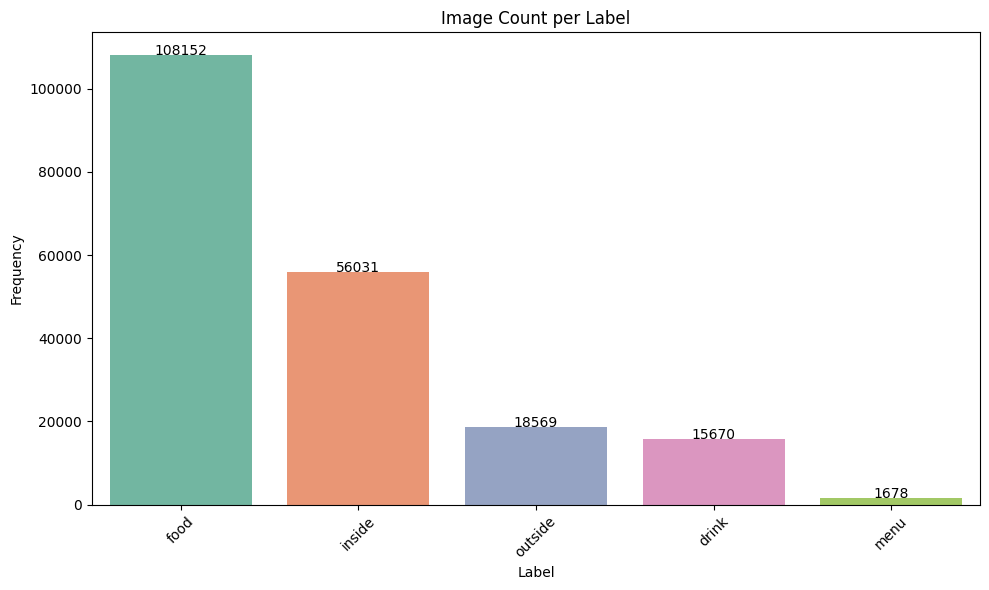

In [10]:
# Plot the distribution
plot_label_distribution(photos_df)

In [11]:
# Photo labels count
photos_df.groupby('label')['photo_id'].count()

label
drink       15670
food       108152
inside      56031
menu         1678
outside     18569
Name: photo_id, dtype: int64

## Balance the Dataset by Undersampling

In [12]:
# Function to balance dataset
def balanced_sample(df, label_col='label'):
    # Find the minimum count across all labels
    min_count = df[label_col].value_counts().min()
    print(f" Sampling {min_count} images per label to ensure class balance.")

    # Perform undersampling for each class
    balanced_df = df.groupby(label_col).apply(lambda x: x.sample(min_count, random_state=42)).reset_index(drop=True)

    print(f" Balanced DataFrame created with {len(balanced_df)} rows across {df[label_col].nunique()} classes.")
    return balanced_df

# Usage
photos_df_balanced = balanced_sample(photos_df)

 Sampling 1678 images per label to ensure class balance.
 Balanced DataFrame created with 8390 rows across 5 classes.


In [13]:
photos_df_balanced.to_csv('balanced_photos_df.csv')

In [14]:
#  Merge the two dataframes on 'business_id'
df = photos_df_balanced.merge(business_df, on="business_id", how="left")

In [15]:
df.shape

(8390, 17)

In [16]:
df.head()

,photo_id,business_id,caption,label,name,address,city,state,postal_code,latitude,longitude,stars,review_count,is_open,attributes,categories,hours
0,Chro0cjWAFLtdv-pmGSB6Q,oBNrLz4EDhiscSlbOl8uAw,Bacon Infused Bloody Mary,drink,Ruby Slipper - New Orleans,200 Magazine St,New Orleans,LA,70130,29.951025,-90.067394,4.5,5193,1,"{'NoiseLevel': ''loud'', 'Caters': 'False', 'B...","Restaurants, American (Traditional), American ...","{'Monday': '0:0-0:0', 'Tuesday': '7:30-14:0', ..."
1,BD8F_GP5TiNCiajFVPqZOA,SV04xdj87VOEa4GJ2dZm_g,,drink,You Cha Cafe,1601 N Kings Hwy,Cherry Hill,NJ,08034,39.916220,-75.007034,4.5,44,1,"{'RestaurantsDelivery': 'True', 'WheelchairAcc...","Bubble Tea, Food, Restaurants, Cafes","{'Monday': '0:0-0:0', 'Tuesday': '11:30-18:0',..."
2,Wo16TBTZHfapyV2n_KbCTQ,EM0jUQn-SEnttG8hf-Eq6A,Huckleberry lemon drop at the bar,drink,Bardenay Restaurant & Distillery - Eagle,155 E Riverside St,Eagle,ID,83616,43.686635,-116.352242,4.0,351,1,"{'GoodForKids': 'True', 'BusinessParking': '{'...","Food, Cocktail Bars, Nightlife, Distilleries, ...","{'Monday': '0:0-0:0', 'Tuesday': '11:0-21:0', ..."
3,1gBfJMbZtrgcqqvgDaYWYA,5Z_KrsEQsPE0ibKwhYn3ZQ,,drink,Signature Grill,3800 W Starr Pass Blvd,Tucson,AZ,85745,32.215561,-111.050749,3.5,105,1,"{'RestaurantsGoodForGroups': 'True', 'OutdoorS...","American (New), Restaurants, Southern, Breakfa...","{'Monday': '17:0-22:0', 'Tuesday': '17:0-22:0'..."
4,Qy65xh-hrmPTb2k_-6uZnA,yd5CI-2fASWsrA92dUR1ZA,,drink,Brewforia Beer Market,"3030 E Overland Rd, Ste 100",Meridian,ID,83642,43.590798,-116.356710,4.0,52,0,"{'BusinessParking': '{'garage': False, 'street...","American (New), Beer, Wine & Spirits, Restaura...","{'Monday': '11:0-22:0', 'Tuesday': '11:0-22:0'..."


## Sample Images by Labels

In [17]:
# Function to show sample images
def show_sample_images(df, img_dir, num_samples=2):
    labels = df['label'].unique()
    n_labels = len(labels)
    fig, axes = plt.subplots(n_labels, num_samples, figsize=(15, 2 * n_labels))

    for i, label in enumerate(labels):
        sample_ids = df[df['label'] == label]['photo_id'].sample(num_samples, random_state=42).tolist()
        for j, photo_id in enumerate(sample_ids):
            img_path = os.path.join(img_dir, f"{photo_id}.jpg")
            try:
                img = Image.open(img_path)
                ax = axes[i, j] if n_labels > 1 else axes[j]
                ax.imshow(img)
                ax.axis('off')
                if j == 0:
                    ax.set_ylabel(label, fontsize=14)
            except Exception:
                # Optionally, you can clear the axis if image loading fails
                ax = axes[i, j] if n_labels > 1 else axes[j]
                ax.axis('off')
    plt.tight_layout()
    plt.show()

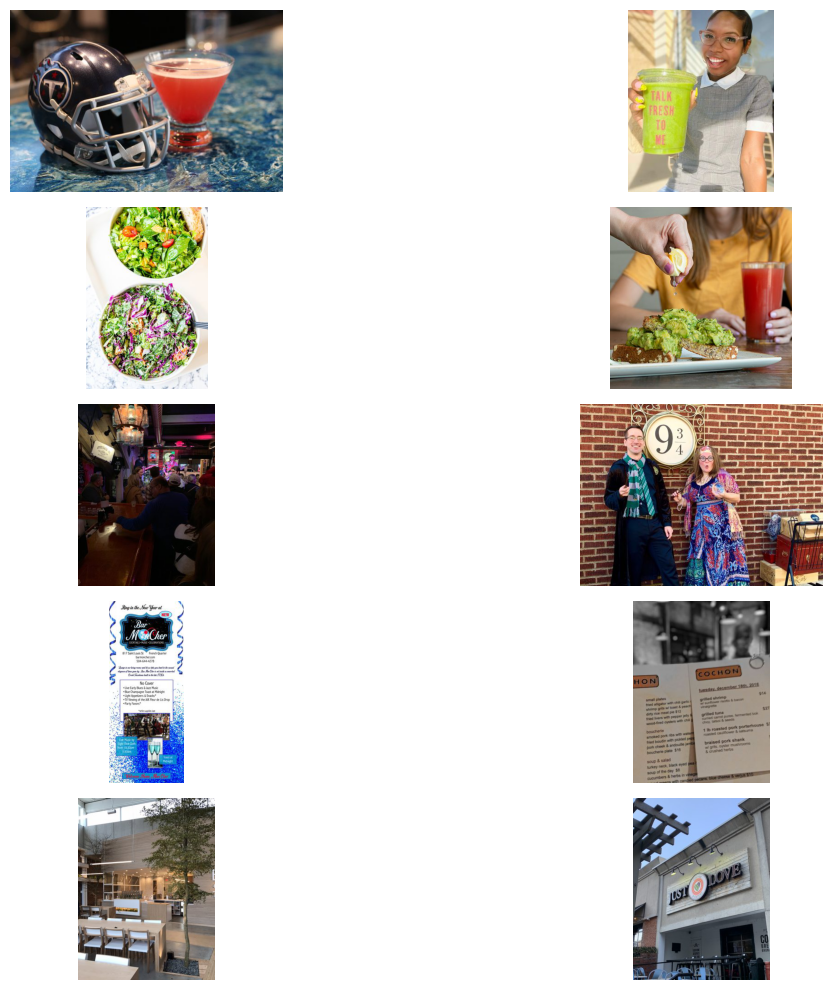

In [18]:
# Show samples
show_sample_images(df, photos_dir, num_samples=2)

## Image Shape Distribution

In [19]:
# Function for image shape distribution
def image_shape_analysis(df, img_dir, sample_size=1000):
    dims = []
    sample_paths = df['photo_id'].sample(sample_size, random_state=42).tolist()

    for photo_id in sample_paths:
        img_path = os.path.join(img_dir, f"{photo_id}.jpg")
        try:
            img = cv2.imread(img_path)
            dims.append(img.shape)
        except:
            continue

    dims = np.array(dims)
    height, width, channels = dims[:, 0], dims[:, 1], dims[:, 2]

    print(f"Average Dimensions: {np.mean(height):.2f} x {np.mean(width):.2f}")
    sns.histplot(height, bins=30, color='blue', kde=True, label='Height')
    sns.histplot(width, bins=30, color='green', kde=True, label='Width')
    plt.title("Image Height and Width Distribution")
    plt.legend()
    plt.show()

    print(f"Color Channels (should mostly be 3): {np.unique(channels, return_counts=True)}")

Average Dimensions: 391.26 x 434.02


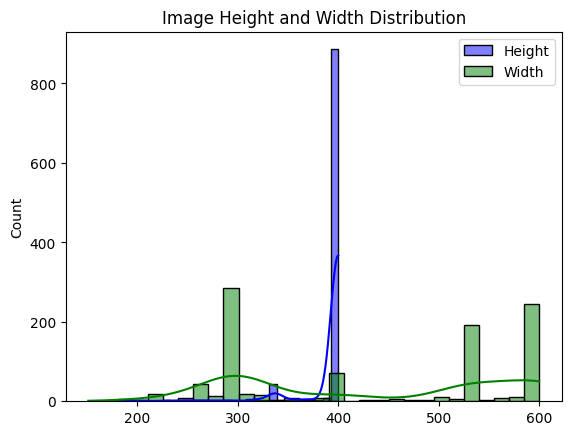

Color Channels (should mostly be 3): (array([3]), array([999], dtype=int64))


In [20]:
# Show image shape distribution
image_shape_analysis(df, img_dir=photos_dir)

## Text Analysis on Caption

In [21]:
# Function to analyze captions
def analyze_captions(df):
    caption_lengths = df['caption'].apply(lambda x: len(str(x).split()))
    print("Caption Word Count Summary:")
    print(caption_lengths.describe())
    
    sns.histplot(caption_lengths, bins=50, kde=True)
    plt.title("Caption Length Distribution")
    plt.xlabel("Number of Words")
    plt.ylabel("Frequency")
    plt.show()

Caption Word Count Summary:
count    8390.000000
mean        2.425626
std         4.044971
min         0.000000
25%         0.000000
50%         0.000000
75%         3.000000
max        31.000000
Name: caption, dtype: float64


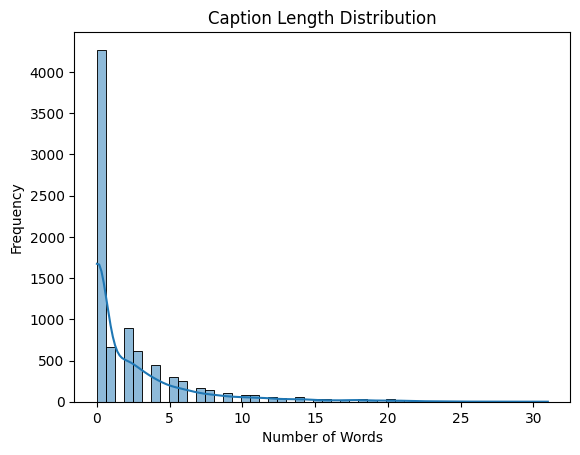

In [22]:
# Show analyzed captions
analyze_captions(df)

In [23]:
# Get image path
df['img_path'] = df['photo_id'].apply(lambda x: os.path.join(photos_dir, f"{x}.jpg"))

In [24]:
#  Check for image file existence
df['exists'] = df['img_path'].apply(os.path.exists)

In [25]:
df.shape

(8390, 19)

In [26]:
# Drop rows without image files
df = df[df['exists']].drop(columns=['exists']).reset_index(drop=True)

In [27]:
# Check info of dataframe
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8390 entries, 0 to 8389
Data columns (total 18 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   photo_id      8390 non-null   object 
 1   business_id   8390 non-null   object 
 2   caption       8390 non-null   object 
 3   label         8390 non-null   object 
 4   name          8390 non-null   object 
 5   address       8390 non-null   object 
 6   city          8390 non-null   object 
 7   state         8390 non-null   object 
 8   postal_code   8390 non-null   object 
 9   latitude      8390 non-null   float64
 10  longitude     8390 non-null   float64
 11  stars         8390 non-null   float64
 12  review_count  8390 non-null   int64  
 13  is_open       8390 non-null   int64  
 14  attributes    8365 non-null   object 
 15  categories    8390 non-null   object 
 16  hours         8163 non-null   object 
 17  img_path      8390 non-null   object 
dtypes: float64(3), int64(2), obj

## Check for Corrupted images

In [28]:
# Function to check for corrupted images
def is_corrupted(photo_id, img_dir):
    img_path = os.path.join(img_dir, f"{photo_id}.jpg")
    try:
        img = Image.open(img_path)
        img.verify()
        return None  # Not corrupted
    except:
        return photo_id  # Corrupted

def check_corrupted_images(df, img_dir='train_photos', max_workers=16):
    corrupted = []

    with ThreadPoolExecutor(max_workers=max_workers) as executor:
        futures = [executor.submit(is_corrupted, pid, img_dir) for pid in df['photo_id']]

        for future in as_completed(futures):
            result = future.result()
            if result:
                corrupted.append(result)

    print(f" Finished checking. Total Corrupted Images: {len(corrupted)}")
    return corrupted

In [29]:
# Show corrupted images
corrupted_ids = check_corrupted_images(df, img_dir=photos_dir)

 Finished checking. Total Corrupted Images: 6


In [30]:
# Remove those rows from the DataFrame
initial_len = len(df)
df_cleaned = df[~df['photo_id'].isin(corrupted_ids)].reset_index(drop=True)

# Print the result
print(f" Cleaned DataFrame: {len(df_cleaned)} rows remaining (removed {initial_len - len(df_cleaned)} corrupted images)")

 Cleaned DataFrame: 8384 rows remaining (removed 6 corrupted images)


In [31]:
df = df_cleaned

In [32]:
df.to_csv('cleaned_photos_df.csv')

## Metadata Preprocessing

In [33]:
# Selected metadata columns
selected_columns = [
    'photo_id', 'business_id', 'label', 'img_path',
    'stars', 'review_count', 'is_open',
    'latitude', 'longitude'
]

In [34]:
# Keep only the selected metadata columns
df = df[selected_columns].copy()

print(" Filtered DataFrame shape:", df.shape)

 Filtered DataFrame shape: (8384, 9)


In [35]:
# Standardization function
def preprocess_metadata(df, scaler=None):
    df = df[['stars', 'review_count', 'is_open', 'latitude', 'longitude']].copy()
    if scaler is None:
        scaler = StandardScaler()
        return scaler.fit_transform(df), scaler
    else:
        return scaler.transform(df), scaler

### Label Encoding

In [36]:
from sklearn.preprocessing import LabelEncoder

# Label Encoder Function
def encode_labels(df, label_col='label'):
    encoder = LabelEncoder()
    df['label_encoded'] = encoder.fit_transform(df[label_col])
    return df, encoder

In [37]:
df, label_encoder = encode_labels(df, label_col='label')

# print df
print(df[['label', 'label_encoded']].head())

   label  label_encoded
0  drink              0
1  drink              0
2  drink              0
3  drink              0
4  drink              0


# Image Processing

In [38]:
# 1. Image Preprocessing
def preprocess_image(img_path, model_type='vgg', target_size=(224, 224)):
    img = cv2.imread(img_path)
    img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
    img = cv2.resize(img, target_size)
    img = cv2.GaussianBlur(img, (5, 5), 0)

    img_yuv = cv2.cvtColor(img, cv2.COLOR_RGB2YUV)
    img_yuv[:, :, 0] = cv2.equalizeHist(img_yuv[:, :, 0])
    img = cv2.cvtColor(img_yuv, cv2.COLOR_YUV2RGB)

    img = np.clip(img, 30, 220)

    if model_type == 'vgg':
        img = vgg_preprocess(img)
    elif model_type == 'effnet':
        img = effnet_preprocess(img)

    return img

In [39]:
# 2. Augmentation Function
def get_augmenter():
    return ImageDataGenerator(
        rotation_range=20,
        zoom_range=0.15,
        width_shift_range=0.2,
        height_shift_range=0.2,
        shear_range=0.15,
        horizontal_flip=True,
        fill_mode="nearest"
    )

In [40]:
# 3. Handling Train/Test Splits
def prepare_train_test(df, model_type='vgg'):
    X_img_paths = df['img_path'].values
    y = df['label_encoded'].values
    X_train_img_paths, X_test_img_paths, y_train, y_test = train_test_split(
        X_img_paths, y, stratify=y, test_size=0.2, random_state=42)

    # Preprocess Images
    X_train_imgs = np.array([preprocess_image(p, model_type=model_type) for p in X_train_img_paths])
    X_test_imgs = np.array([preprocess_image(p, model_type=model_type) for p in X_test_img_paths])

    # Preprocess Metadata with shared scaler
    train_df = df[df['img_path'].isin(X_train_img_paths)]
    test_df = df[df['img_path'].isin(X_test_img_paths)]

    X_train_meta, scaler = preprocess_metadata(train_df)
    X_test_meta, _ = preprocess_metadata(test_df, scaler)

    return X_train_imgs, X_test_imgs, X_train_meta, X_test_meta, y_train, y_test

### Train_Test Split

In [41]:
# Run train-test preparation for VGG Model
X_train_imgs_vgg, X_test_imgs_vgg, X_train_meta_vgg, X_test_meta_vgg, y_train_vgg, y_test_vgg = prepare_train_test(df, model_type='vgg')

# Print shapes
print("X_train_imgs shape:", X_train_imgs_vgg.shape)
print("X_test_imgs shape:", X_test_imgs_vgg.shape)
print("X_train_meta shape:", X_train_meta_vgg.shape)
print("X_test_meta shape:", X_test_meta_vgg.shape)
print("y_train shape:", y_train_vgg.shape)
print("y_test shape:", y_test_vgg.shape)

X_train_imgs shape: (6707, 224, 224, 3)
X_test_imgs shape: (1677, 224, 224, 3)
X_train_meta shape: (6707, 5)
X_test_meta shape: (1677, 5)
y_train shape: (6707,)
y_test shape: (1677,)


In [42]:
# Run train-test preparation for EfficientNet Model
X_train_imgs_effnet, X_test_imgs_effnet, X_train_meta_effnet, X_test_meta_effnet, y_train_effnet, y_test_effnet = prepare_train_test(df, model_type='effnet')

# Print shapes
print("X_train_imgs shape:", X_train_imgs_effnet.shape)
print("X_test_imgs shape:", X_test_imgs_effnet.shape)
print("X_train_meta shape:", X_train_meta_effnet.shape)
print("X_test_meta shape:", X_test_meta_effnet.shape)
print("y_train shape:", y_train_effnet.shape)
print("y_test shape:", y_test_effnet.shape)

X_train_imgs shape: (6707, 224, 224, 3)
X_test_imgs shape: (1677, 224, 224, 3)
X_train_meta shape: (6707, 5)
X_test_meta shape: (1677, 5)
y_train shape: (6707,)
y_test shape: (1677,)
